# U1 - Heladas y Lluvia: Monitoreo y anticipación de riesgo climático en Juliaca

**Equipo:** BIG IMPACT · **Integrante:** Efrain Nayder Arce Mayta
**Dimensión:** Precipitación — predictiva, batch (U1)

## 1.1 Crear el notebook y la SparkSession

In [1]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("bigdata-u1-precipitacion")
    .master("local[*]")
    .config("spark.ui.port", "4040")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/09 13:07:53 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/09 13:07:54 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/09/09 13:07:54 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


## 1.2 Definir el esquema y cargar los datos

In [2]:
from pyspark.sql.types import StructType, StructField, TimestampType, DoubleType

ORIGEN_DATOS = "/opt/bigdata-u1/data"

schema_clima = StructType([
    StructField("time", TimestampType(), nullable=False),
    StructField("temperature_2m", DoubleType(), nullable=True),
    StructField("precipitation", DoubleType(), nullable=True),
    StructField("relative_humidity_2m", DoubleType(), nullable=True),
    StructField("cloud_cover", DoubleType(), nullable=True),
    StructField("wind_speed_10m", DoubleType(), nullable=True),
    StructField("surface_pressure", DoubleType(), nullable=True),
])

df = (
    spark.read
    .option("timestampFormat", "yyyy-MM-dd'T'HH:mm")
    .csv(f"{ORIGEN_DATOS}/clima_juliaca_horario.csv", header=True, schema=schema_clima)
)

df.printSchema()
df.show(5)
print(f"Total filas: {df.count():,}")

root
 |-- time: timestamp (nullable = true)
 |-- temperature_2m: double (nullable = true)
 |-- precipitation: double (nullable = true)
 |-- relative_humidity_2m: double (nullable = true)
 |-- cloud_cover: double (nullable = true)
 |-- wind_speed_10m: double (nullable = true)
 |-- surface_pressure: double (nullable = true)

+-------------------+--------------+-------------+--------------------+-----------+--------------+----------------+
|               time|temperature_2m|precipitation|relative_humidity_2m|cloud_cover|wind_speed_10m|surface_pressure|
+-------------------+--------------+-------------+--------------------+-----------+--------------+----------------+
|2010-01-01 00:00:00|           6.8|          0.0|                84.0|       93.0|           4.9|           645.3|
|2010-01-01 01:00:00|           5.5|          0.0|                91.0|       89.0|           6.2|           643.7|
|2010-01-01 02:00:00|           5.5|          0.0|                83.0|       91.0|           6

## 1.3 Verificar nulos en todas las columnas

In [3]:
from pyspark.sql.functions import col, count as spark_count, when

df.select([
    spark_count(when(col(c).isNull(), c)).alias(c) for c in df.columns
]).show(vertical=True, truncate=False)

[Stage 4:=============================>                             (1 + 1) / 2]

-RECORD 0-------------------
 time                 | 0   
 temperature_2m       | 0   
 precipitation        | 0   
 relative_humidity_2m | 0   
 cloud_cover          | 0   
 wind_speed_10m       | 0   
 surface_pressure     | 0   



## 1.4 Gráfico de verificación de nulos

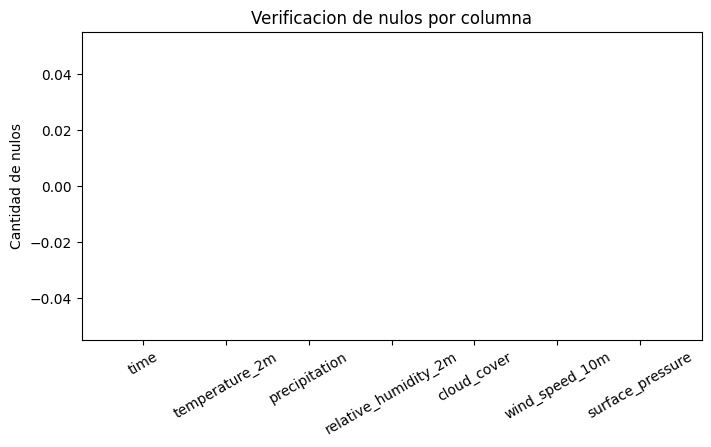

In [22]:
nulos_dict = {c: df.filter(col(c).isNull()).count() for c in df.columns}

plt.figure(figsize=(8, 4))
plt.bar(nulos_dict.keys(), nulos_dict.values(), color="firebrick")
plt.ylabel("Cantidad de nulos")
plt.title("Verificacion de nulos por columna")
plt.xticks(rotation=30)
plt.show()

## 1.5 Agregar a valores diarios

In [4]:
from pyspark.sql.functions import to_date, sum as spark_sum, avg

df_diario = (
    df
    .withColumn("fecha", to_date(col("time")))
    .groupBy("fecha")
    .agg(
        spark_sum("precipitation").alias("precip_acum_dia"),
        avg("relative_humidity_2m").alias("humedad_prom_dia"),
        avg("cloud_cover").alias("nubosidad_prom_dia"),
        avg("surface_pressure").alias("presion_prom_dia"),
    )
)

df_diario.orderBy("fecha").show(5)
print(f"Total dias: {df_diario.count():,}")

+----------+------------------+-----------------+------------------+-----------------+
|     fecha|   precip_acum_dia| humedad_prom_dia|nubosidad_prom_dia| presion_prom_dia|
+----------+------------------+-----------------+------------------+-----------------+
|2010-01-01|2.5999999999999996|65.29166666666667| 83.95833333333333|645.9083333333333|
|2010-01-02|               6.7|75.54166666666667| 83.45833333333333|          645.525|
|2010-01-03|               6.0|73.79166666666667|             99.25|646.1166666666667|
|2010-01-04|              10.1|79.33333333333333|             99.25|646.1625000000001|
|2010-01-05|               3.7|77.79166666666667|            90.125|            647.1|
+----------+------------------+-----------------+------------------+-----------------+
only showing top 5 rows
Total dias: 6,095


## 1.5.1 Procesamiento con RDD (evidencia de bajo nivel)

In [27]:
conteo_rdd = df_diario.rdd.filter(lambda fila: fila["hay_lluvia_intensa"] == 1.0).count()
print(f"Dias con lluvia intensa (via RDD): {conteo_rdd:,}")

[Stage 577:>                                                        (0 + 1) / 1]

Dias con lluvia intensa (via RDD): 2,164


## 1.6 Resumen mensual y gráfico de tendencia

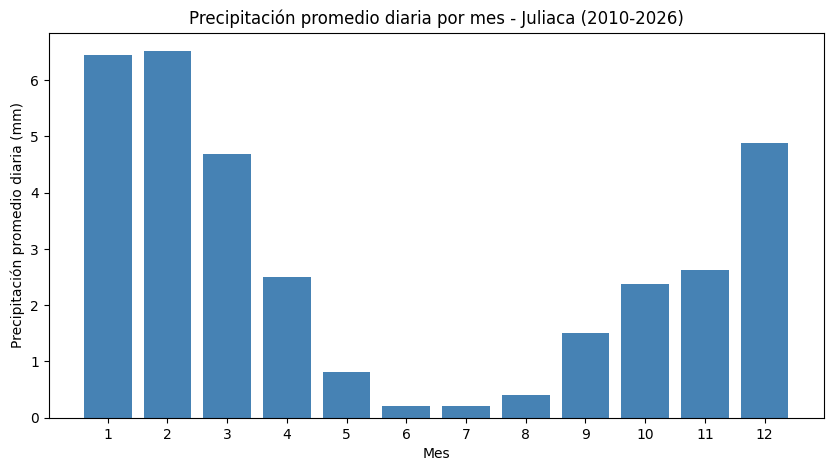

In [5]:
from pyspark.sql.functions import month
import matplotlib.pyplot as plt

resumen_mensual = (
    df_diario
    .withColumn("mes", month(col("fecha")))
    .groupBy("mes")
    .agg(avg("precip_acum_dia").alias("precip_prom_dia"))
    .orderBy("mes")
    .toPandas()
)

plt.figure(figsize=(10, 5))
plt.bar(resumen_mensual["mes"], resumen_mensual["precip_prom_dia"], color="steelblue")
plt.xlabel("Mes")
plt.ylabel("Precipitación promedio diaria (mm)")
plt.title("Precipitación promedio diaria por mes - Juliaca (2010-2026)")
plt.xticks(range(1, 13))
plt.show()


## 1.7 Marcar lluvia intensa y codificar el día del año (cíclico)

In [6]:
from pyspark.sql.functions import when, dayofyear, sin, cos
import math

UMBRAL_LLUVIA = 2.0

df_diario = (
    df_diario
    .withColumn("hay_lluvia_intensa", when(col("precip_acum_dia") > UMBRAL_LLUVIA, 1.0).otherwise(0.0))
    .withColumn("dia_anio", dayofyear(col("fecha")))
    .withColumn("dia_sin", sin(col("dia_anio") * (2 * math.pi / 365)))
    .withColumn("dia_cos", cos(col("dia_anio") * (2 * math.pi / 365)))
)

df_diario.select("fecha", "precip_acum_dia", "hay_lluvia_intensa", "dia_anio", "dia_sin", "dia_cos").show(5)

+----------+------------------+------------------+--------+------------------+------------------+
|     fecha|   precip_acum_dia|hay_lluvia_intensa|dia_anio|           dia_sin|           dia_cos|
+----------+------------------+------------------+--------+------------------+------------------+
|2010-01-15|13.999999999999995|               1.0|      15| 0.255353295116187|0.9668478136052775|
|2010-01-16| 6.700000000000001|               1.0|      16|0.2719581575341055|0.9623090774541486|
|2010-01-30|1.4000000000000001|               0.0|      30|0.4937755501599772| 0.869589389346611|
|2010-01-31|               3.5|               1.0|      31|0.5086709438521044|0.8609610158889943|
|2010-02-11|               0.0|               0.0|      42|0.6616346182422783|0.7498264012045686|
+----------+------------------+------------------+--------+------------------+------------------+
only showing top 5 rows


## 1.8 Evidencia del plan de ejecución (lazy evaluation)

In [7]:
df_diario.explain(True)

== Parsed Logical Plan ==
'Project [unresolvedstarwithcolumns(dia_cos, 'cos('`*`('dia_anio, 0.01721420632103996)), None)]
+- Project [fecha#112, precip_acum_dia#113, humedad_prom_dia#114, nubosidad_prom_dia#115, presion_prom_dia#116, hay_lluvia_intensa#217, dia_anio#218, SIN((cast(dia_anio#218 as double) * 0.01721420632103996)) AS dia_sin#219]
   +- Project [fecha#112, precip_acum_dia#113, humedad_prom_dia#114, nubosidad_prom_dia#115, presion_prom_dia#116, hay_lluvia_intensa#217, dayofyear(fecha#112) AS dia_anio#218]
      +- Project [fecha#112, precip_acum_dia#113, humedad_prom_dia#114, nubosidad_prom_dia#115, presion_prom_dia#116, CASE WHEN (precip_acum_dia#113 > 2.0) THEN 1.0 ELSE 0.0 END AS hay_lluvia_intensa#217]
         +- Aggregate [fecha#112], [fecha#112, sum(precipitation#2) AS precip_acum_dia#113, avg(relative_humidity_2m#3) AS humedad_prom_dia#114, avg(cloud_cover#4) AS nubosidad_prom_dia#115, avg(surface_pressure#6) AS presion_prom_dia#116]
            +- Project [time#0, 

## 1.9 Verificar duplicados

In [8]:
total = df_diario.count()
sin_duplicar = df_diario.dropDuplicates(["fecha"]).count()

print(f"Total: {total:,}, sin duplicar por fecha: {sin_duplicar:,}")
assert total == sin_duplicar, "Hay fechas duplicadas en la agregacion diaria"

Total: 6,095, sin duplicar por fecha: 6,095


## 1.10 Escribir salida Gold en Parquet, particionada por año

In [9]:
from pyspark.sql.functions import year

RUTA_GOLD = "/opt/bigdata-u1/artifacts/precipitacion_gold"

df_diario_particionable = df_diario.withColumn("anio", year(col("fecha")))

(
    df_diario_particionable
    .repartition(4)
    .write.format("parquet")
    .mode("overwrite")
    .partitionBy("anio")
    .save(RUTA_GOLD)
)

import os
print("Carpetas de particion creadas:")
for carpeta in sorted(os.listdir(RUTA_GOLD)):
    print(" -", carpeta)

Carpetas de particion creadas:
 - ._SUCCESS.crc
 - _SUCCESS
 - anio=2010
 - anio=2011
 - anio=2012
 - anio=2013
 - anio=2014
 - anio=2015
 - anio=2016
 - anio=2017
 - anio=2018
 - anio=2019
 - anio=2020
 - anio=2021
 - anio=2022
 - anio=2023
 - anio=2024
 - anio=2025
 - anio=2026


## 1.11 Verificar lectura de vuelta y PartitionFilters

In [10]:
df_gold = spark.read.parquet(RUTA_GOLD)

total_original = df_diario_particionable.count()
total_leido = df_gold.count()
print(f"Filas escritas: {total_original:,}, filas leidas de vuelta: {total_leido:,}")
assert total_original == total_leido, "Se perdieron filas al escribir/leer el Parquet"

df_gold.filter(col("anio") == 2022).explain()

[Stage 57:====>                                                   (1 + 11) / 12]

Filas escritas: 6,095, filas leidas de vuelta: 6,095
== Physical Plan ==
*(1) ColumnarToRow
+- FileScan parquet [fecha#322,precip_acum_dia#323,humedad_prom_dia#324,nubosidad_prom_dia#325,presion_prom_dia#326,hay_lluvia_intensa#327,dia_anio#328,dia_sin#329,dia_cos#330,anio#331] Batched: true, DataFilters: [], Format: Parquet, Location: InMemoryFileIndex(1 paths)[file:/opt/bigdata-u1/artifacts/precipitacion_gold], PartitionFilters: [isnotnull(anio#331), (anio#331 = 2022)], PushedFilters: [], ReadSchema: struct<fecha:date,precip_acum_dia:double,humedad_prom_dia:double,nubosidad_prom_dia:double,presio...




## 1.12 Resumen mensual (probabilidad de lluvia intensa) y gráfico de tendencia

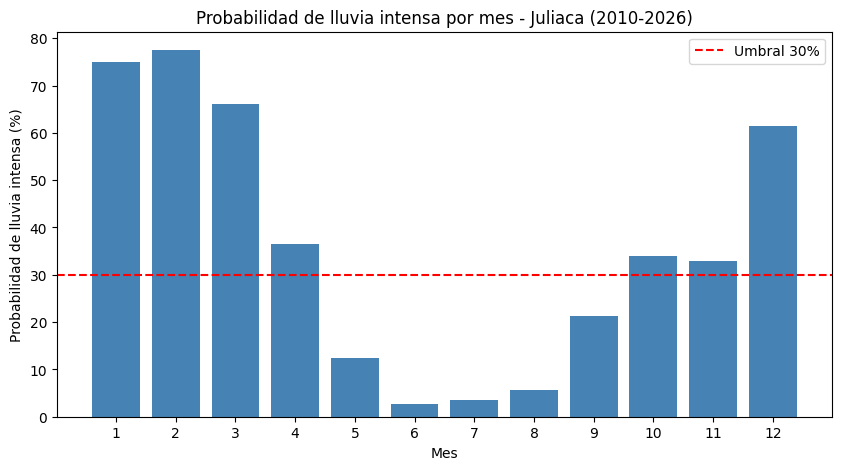

In [15]:
resumen_mensual = (
    df_diario
    .withColumn("mes", month(col("fecha")))
    .groupBy("mes")
    .agg(avg("hay_lluvia_intensa").alias("prob_lluvia"))
    .orderBy("mes")
    .toPandas()
)

plt.figure(figsize=(10, 5))
plt.bar(resumen_mensual["mes"], resumen_mensual["prob_lluvia"] * 100, color="steelblue")
plt.axhline(y=30, color="red", linestyle="--", label="Umbral 30%")
plt.xlabel("Mes")
plt.ylabel("Probabilidad de lluvia intensa (%)")
plt.title("Probabilidad de lluvia intensa por mes - Juliaca (2010-2026)")
plt.xticks(range(1, 13))
plt.legend()
plt.show()

## 1.13 Distribución de precipitación diaria por mes (boxplot)

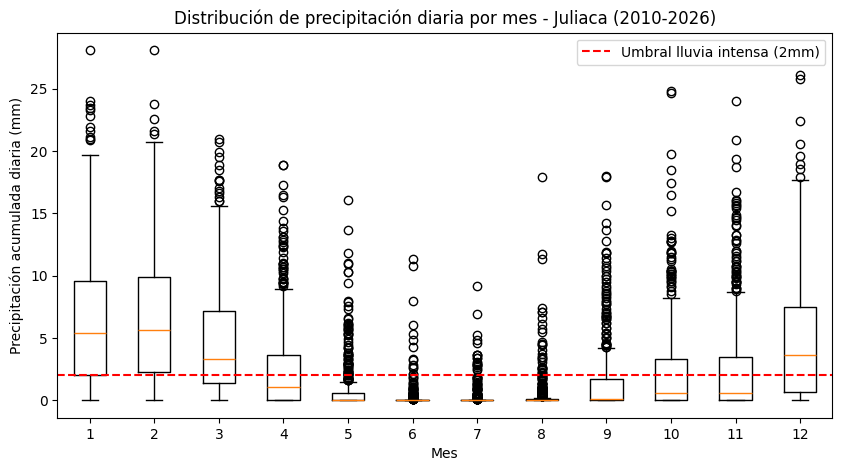

In [16]:
datos_boxplot = (
    df_diario
    .withColumn("mes", month(col("fecha")))
    .select("mes", "precip_acum_dia")
    .toPandas()
)

grupos = [datos_boxplot[datos_boxplot["mes"] == m]["precip_acum_dia"].values for m in range(1, 13)]

plt.figure(figsize=(10, 5))
plt.boxplot(grupos, tick_labels=range(1, 13))
plt.axhline(y=2, color="red", linestyle="--", label="Umbral lluvia intensa (2mm)")
plt.xlabel("Mes")
plt.ylabel("Precipitación acumulada diaria (mm)")
plt.title("Distribución de precipitación diaria por mes - Juliaca (2010-2026)")
plt.legend()
plt.show()

## 1.14 Correlación de cada variable con la lluvia intensa

In [19]:
import pandas as pd

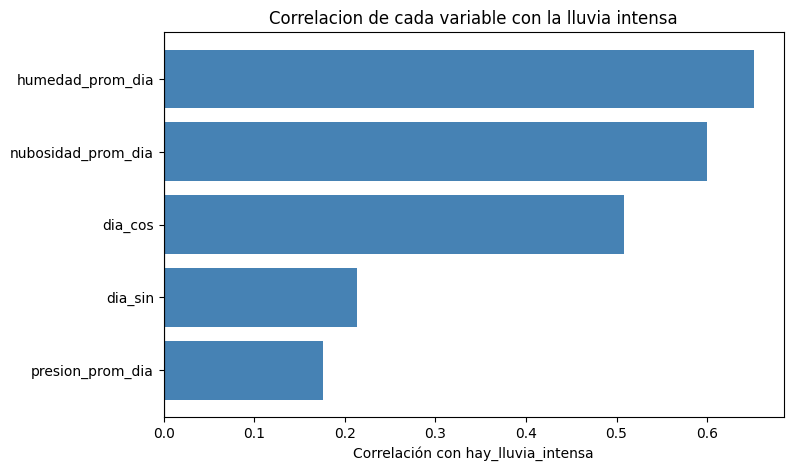

In [20]:
predictores_candidatos = ["dia_sin", "dia_cos", "humedad_prom_dia", "nubosidad_prom_dia", "presion_prom_dia"]

correlaciones = {
    p: df_diario.stat.corr(p, "hay_lluvia_intensa")
    for p in predictores_candidatos
}

df_corr = pd.DataFrame(list(correlaciones.items()), columns=["variable", "correlacion"]).sort_values("correlacion")

plt.figure(figsize=(8, 5))
plt.barh(df_corr["variable"], df_corr["correlacion"], color="steelblue")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.xlabel("Correlación con hay_lluvia_intensa")
plt.title("Correlacion de cada variable con la lluvia intensa")
plt.show()

## 1.15 Matriz de correlación completa

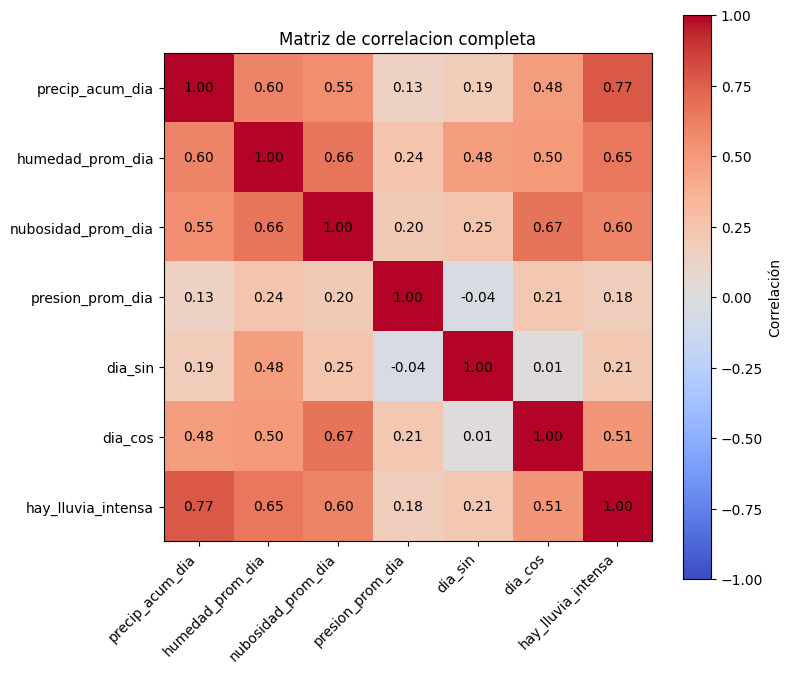

In [21]:
import numpy as np

variables_matriz = ["precip_acum_dia", "humedad_prom_dia", "nubosidad_prom_dia", "presion_prom_dia", "dia_sin", "dia_cos", "hay_lluvia_intensa"]

matriz = np.zeros((len(variables_matriz), len(variables_matriz)))
for i, v1 in enumerate(variables_matriz):
    for j, v2 in enumerate(variables_matriz):
        matriz[i, j] = df_diario.stat.corr(v1, v2)

plt.figure(figsize=(8, 7))
plt.imshow(matriz, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlación")
plt.xticks(range(len(variables_matriz)), variables_matriz, rotation=45, ha="right")
plt.yticks(range(len(variables_matriz)), variables_matriz)
for i in range(len(variables_matriz)):
    for j in range(len(variables_matriz)):
        plt.text(j, i, f"{matriz[i, j]:.2f}", ha="center", va="center", color="black")
plt.title("Matriz de correlacion completa")
plt.tight_layout()
plt.show()

## 1.16 Vectores de predictores (dos configuraciones) y división train/test

In [11]:
from pyspark.ml.feature import VectorAssembler

assembler_simple = VectorAssembler(
    inputCols=["dia_sin", "dia_cos"],
    outputCol="features_simple"
)

assembler_enriquecido = VectorAssembler(
    inputCols=["dia_sin", "dia_cos", "humedad_prom_dia", "nubosidad_prom_dia", "presion_prom_dia"],
    outputCol="features_enriquecido"
)

df_features = assembler_simple.transform(df_gold)
df_features = assembler_enriquecido.transform(df_features)

df_train, df_test = df_features.randomSplit([0.8, 0.2], seed=42)

print(f"Filas train: {df_train.count():,}")
print(f"Filas test: {df_test.count():,}")

Filas train: 4,896


[Stage 63:==========================================>              (9 + 3) / 12]

Filas test: 1,199


## 1.17 Entrenar y evaluar Config A (solo estacionalidad)

In [12]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

log_simple = LogisticRegression(featuresCol="features_simple", labelCol="hay_lluvia_intensa")
modelo_log_simple = log_simple.fit(df_train)

predicciones_log_simple = modelo_log_simple.transform(df_test)

evaluador_auc = BinaryClassificationEvaluator(labelCol="hay_lluvia_intensa", metricName="areaUnderROC")
evaluador_f1 = MulticlassClassificationEvaluator(labelCol="hay_lluvia_intensa", predictionCol="prediction", metricName="f1")

auc_simple = evaluador_auc.evaluate(predicciones_log_simple)
f1_simple = evaluador_f1.evaluate(predicciones_log_simple)

print(f"Config A (solo dia del anio) -> AUC: {auc_simple:.4f}, F1: {f1_simple:.4f}")

netlib-blas: JNI_OnLoad: dlopen(libblas.so.3) failed: libblas.so.3: cannot open shared object file: No such file or directory
[Stage 104:====>                                                  (1 + 11) / 12]

Config A (solo dia del anio) -> AUC: 0.8369, F1: 0.7728


## 1.18 Entrenar y evaluar Config B (estacionalidad + contexto meteorológico)

In [13]:
log_enriquecido = LogisticRegression(featuresCol="features_enriquecido", labelCol="hay_lluvia_intensa")
modelo_log_enriquecido = log_enriquecido.fit(df_train)

predicciones_log_enriquecido = modelo_log_enriquecido.transform(df_test)

auc_enriquecido = evaluador_auc.evaluate(predicciones_log_enriquecido)
f1_enriquecido = evaluador_f1.evaluate(predicciones_log_enriquecido)

print(f"Config B (dia + humedad + nubosidad + presion) -> AUC: {auc_enriquecido:.4f}, F1: {f1_enriquecido:.4f}")

Config B (dia + humedad + nubosidad + presion) -> AUC: 0.9425, F1: 0.8737


## 1.18.1 Métricas adicionales: precisión y exhaustividad

In [28]:
evaluador_precision = MulticlassClassificationEvaluator(labelCol="hay_lluvia_intensa", predictionCol="prediction", metricName="weightedPrecision")
evaluador_recall = MulticlassClassificationEvaluator(labelCol="hay_lluvia_intensa", predictionCol="prediction", metricName="weightedRecall")

precision_b = evaluador_precision.evaluate(predicciones_log_enriquecido)
recall_b = evaluador_recall.evaluate(predicciones_log_enriquecido)

print(f"Config B -> Precision: {precision_b:.4f}, Recall: {recall_b:.4f}")

Config B -> Precision: 0.8745, Recall: 0.8732


## 1.19 Matriz de confusión - Config B

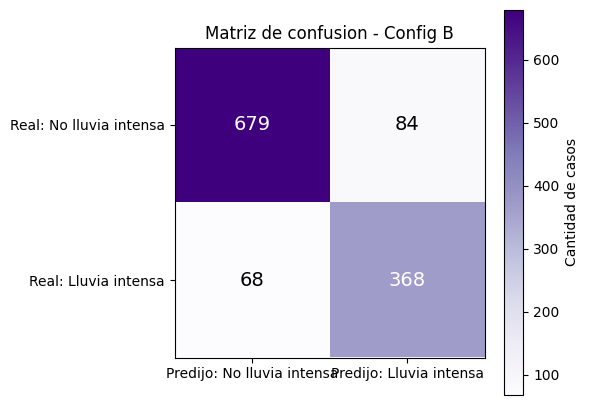

In [23]:
conf_matrix = (
    predicciones_log_enriquecido
    .groupBy("hay_lluvia_intensa", "prediction")
    .count()
    .toPandas()
)

tabla = conf_matrix.pivot(index="hay_lluvia_intensa", columns="prediction", values="count").fillna(0)

plt.figure(figsize=(5, 5))
plt.imshow(tabla.values, cmap="Purples")
plt.colorbar(label="Cantidad de casos")
plt.xticks([0, 1], ["Predijo: No lluvia intensa", "Predijo: Lluvia intensa"])
plt.yticks([0, 1], ["Real: No lluvia intensa", "Real: Lluvia intensa"])

maximo = tabla.values.max()
for i in range(tabla.shape[0]):
    for j in range(tabla.shape[1]):
        valor = tabla.values[i, j]
        color_texto = "white" if valor > maximo * 0.5 else "black"
        plt.text(j, i, int(valor), ha="center", va="center", color=color_texto, fontsize=14)

plt.title("Matriz de confusion - Config B")
plt.show()

## 1.20 Matriz de confusión - Config A

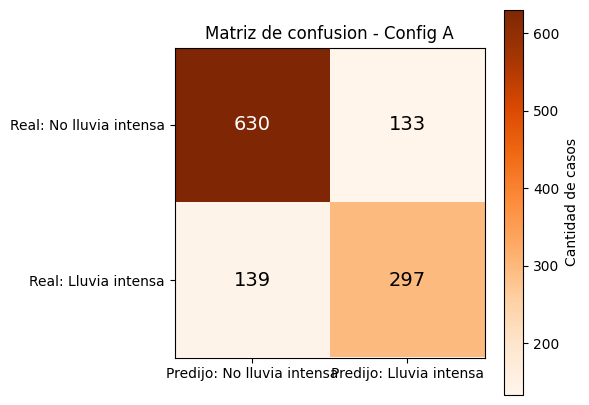

In [24]:
conf_matrix_a = (
    predicciones_log_simple
    .groupBy("hay_lluvia_intensa", "prediction")
    .count()
    .toPandas()
)

tabla_a = conf_matrix_a.pivot(index="hay_lluvia_intensa", columns="prediction", values="count").fillna(0)

plt.figure(figsize=(5, 5))
plt.imshow(tabla_a.values, cmap="Oranges")
plt.colorbar(label="Cantidad de casos")
plt.xticks([0, 1], ["Predijo: No lluvia intensa", "Predijo: Lluvia intensa"])
plt.yticks([0, 1], ["Real: No lluvia intensa", "Real: Lluvia intensa"])

maximo = tabla_a.values.max()
for i in range(tabla_a.shape[0]):
    for j in range(tabla_a.shape[1]):
        valor = tabla_a.values[i, j]
        color_texto = "white" if valor > maximo * 0.5 else "black"
        plt.text(j, i, int(valor), ha="center", va="center", color=color_texto, fontsize=14)

plt.title("Matriz de confusion - Config A")
plt.show()

## 1.21 Guardar el modelo ganador

In [14]:
RUTA_MODELO = "/opt/bigdata-u1/artifacts/modelo_precipitacion_config_b"

modelo_log_enriquecido.write().overwrite().save(RUTA_MODELO)

print(f"Modelo guardado en: {RUTA_MODELO}")

Modelo guardado en: /opt/bigdata-u1/artifacts/modelo_precipitacion_config_b
